# Campaign Revenue Prediction with Regression

This project explores how creator, campaign, and audience characteristics relate to campaign revenue. It uses regression models to estimate revenue for future campaigns and support campaign planning.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../raw_data/influencer_campaign_regression - influencer_campaign_regression.csv")
df.head()

,creator_followers_k,engagement_rate_pct,paid_boost_spend_usd,avg_watch_time_sec,promo_discount_pct,content_format,audience_intent_tier,caption_word_count,hashtags_used_count,creator_phone_os,contract_payment_terms,posting_day_weather,campaign_revenue_usd
0,425.4,2.14,1331,35.2,10,Static-Carousel,High-Intent-Niche,35,16,Android,Net-30,Sunny,15192.26
1,171.3,5.73,3925,25.4,10,YouTube-Deep-Dive,Lifestyle-Warm,26,16,Android,Upfront,Cloudy,20018.44
2,356.4,8.03,1817,9.4,0,Short-Video-Reel,High-Intent-Niche,43,24,Android,Upfront,Cloudy,21146.87
3,272.2,7.70,942,32.1,15,Short-Video-Reel,Lifestyle-Warm,113,9,Android,Net-15,Rainy,17639.62
4,143.0,6.06,3347,51.0,20,Short-Video-Reel,Broad-Entertainment,72,18,Android,Net-30,Cloudy,17375.60


## Dataset Overview

The CSV is loaded into a pandas DataFrame named `df`. The first rows provide a quick check of the available columns and values; the following summary cells inspect the dataset's size, data types, distributions, missing values, and duplicate rows before analysis.

# Problem Definition

## 1. Business Problem

Brands work with creators and allocate budgets to promote campaigns, but campaign revenue varies. This project uses historical campaign data to estimate the revenue of future campaigns and help inform creator selection and budget planning.

### Prediction Target

The target is `campaign_revenue_usd`, a continuous measure of campaign revenue in USD. A regression model is appropriate because the goal is to estimate a numeric value rather than assign a category.

### Intended Use

Predictions can support planning and comparison, but they should be considered alongside costs, uncertainty, and business context. The model identifies patterns in the available data; it does not establish that a feature causes revenue to increase.

## 2. Target and Candidate Features

**Target:** `campaign_revenue_usd`, the revenue value the models aim to estimate.

**Candidate predictors in the source data:**

- `creator_followers_k`: creator audience size.
- `engagement_rate_pct`: audience engagement rate.
- `paid_boost_spend_usd`: paid promotion spend.
- `avg_watch_time_sec`: average viewing time.
- `promo_discount_pct`: campaign discount level.
- `content_format`: format used for the campaign content.
- `audience_intent_tier`: audience purchase-intent category.
- `caption_word_count`: length of the campaign caption.
- `hashtags_used_count`: number of hashtags used.
- `contract_payment_terms`: payment arrangement with the creator.
- `posting_day_weather`: weather category on the posting day.
- `creator_phone_os`: creator's phone operating system.

These are candidate fields from the raw data; the preprocessing section below documents which ones are retained for the models.

## 3. Modeling Approach

This is a supervised regression task: the historical campaign features are inputs, and `campaign_revenue_usd` is the continuous target. Linear Regression and degree-two Polynomial Regression provide linear-model baselines; KNN, a Decision Tree, and a Random Forest provide additional model families that can capture nonlinear patterns. Validation data is used for model selection, with the test partition reserved for evaluation.

# Data Understanding & EDA

In [2]:
display(df.shape)
print()
print("-"*50)
print()
display(df.info())
print()
print("-"*50)
print()
display(df.describe())

(3000, 13)


--------------------------------------------------

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   creator_followers_k     3000 non-null   float64
 1   engagement_rate_pct     3000 non-null   float64
 2   paid_boost_spend_usd    3000 non-null   int64  
 3   avg_watch_time_sec      3000 non-null   float64
 4   promo_discount_pct      3000 non-null   int64  
 5   content_format          3000 non-null   str    
 6   audience_intent_tier    3000 non-null   str    
 7   caption_word_count      3000 non-null   int64  
 8   hashtags_used_count     3000 non-null   int64  
 9   creator_phone_os        3000 non-null   str    
 10  contract_payment_terms  3000 non-null   str    
 11  posting_day_weather     3000 non-null   str    
 12  campaign_revenue_usd    3000 non-null   float64
dtypes: float64(4), int64(4), str(5)
memory usage: 304.8

None


--------------------------------------------------



,creator_followers_k,engagement_rate_pct,paid_boost_spend_usd,avg_watch_time_sec,promo_discount_pct,caption_word_count,hashtags_used_count,campaign_revenue_usd
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,232.592433,5.161417,2317.529667,30.266467,12.358333,86.810000,12.367000,16678.699140
std,126.675186,2.539730,1273.365953,14.147323,8.613245,42.942674,6.996473,4747.136562
min,15.000000,0.800000,100.000000,6.100000,0.000000,12.000000,1.000000,2915.630000
25%,122.400000,2.927500,1208.750000,17.900000,5.000000,50.000000,6.000000,13222.897500
50%,229.800000,5.180000,2370.000000,30.400000,10.000000,86.000000,13.000000,16480.745000
75%,343.725000,7.410000,3416.250000,42.700000,20.000000,124.000000,18.000000,19839.157500
max,449.900000,9.500000,4499.000000,55.000000,25.000000,159.000000,24.000000,32527.890000


In [3]:
display("Duplicated Values:", df.duplicated().sum())
display("Null Values:", df.isnull().sum())

'Duplicated Values:'

np.int64(0)

'Null Values:'

creator_followers_k       0
engagement_rate_pct       0
paid_boost_spend_usd      0
avg_watch_time_sec        0
promo_discount_pct        0
content_format            0
audience_intent_tier      0
caption_word_count        0
hashtags_used_count       0
creator_phone_os          0
contract_payment_terms    0
posting_day_weather       0
campaign_revenue_usd      0
dtype: int64

These checks quantify duplicate rows and missing values before modeling. Duplicate records can overweight repeated campaigns, while missing values may require removal or imputation; the choices should be based on these reported counts rather than assumed.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
def showBoxPlot(data, col):
    plt.title(f"Distribution for {col}")
    plt.xlabel(f"{col}")
    sns.boxplot(data[col])
    plt.show()

In [6]:
df.describe().columns

Index(['creator_followers_k', 'engagement_rate_pct', 'paid_boost_spend_usd',
       'avg_watch_time_sec', 'promo_discount_pct', 'caption_word_count',
       'hashtags_used_count', 'campaign_revenue_usd'],
      dtype='str')

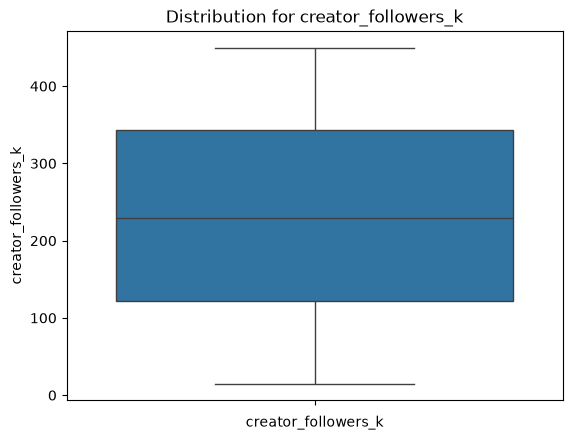

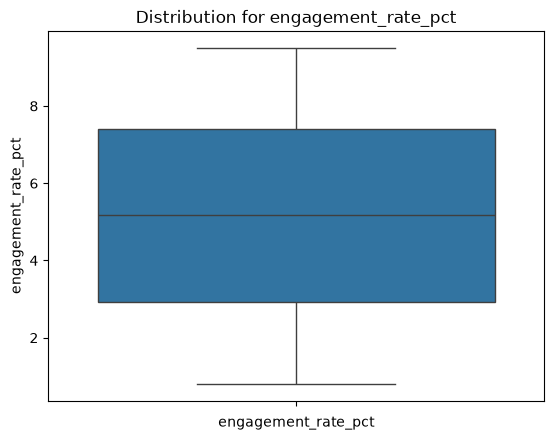

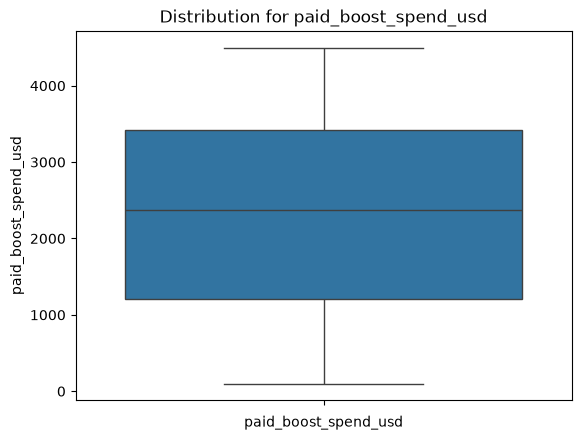

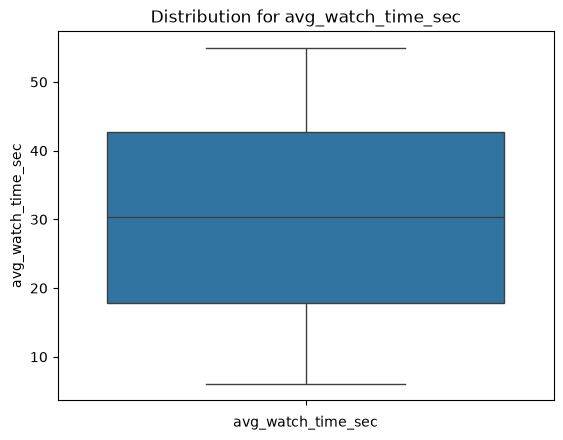

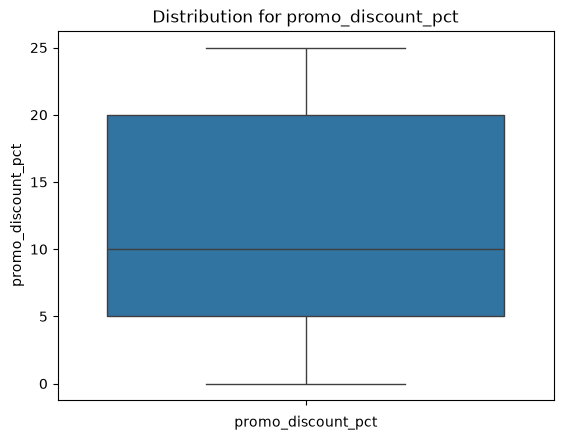

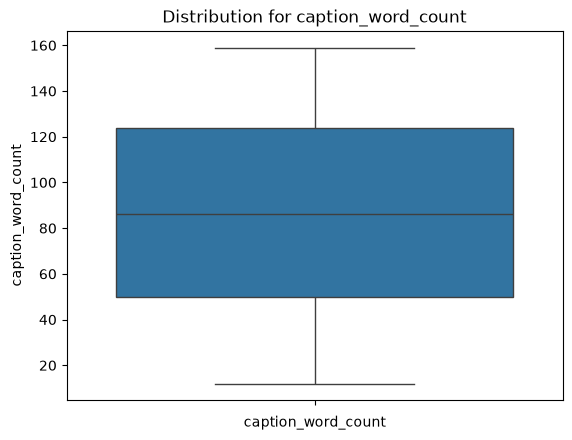

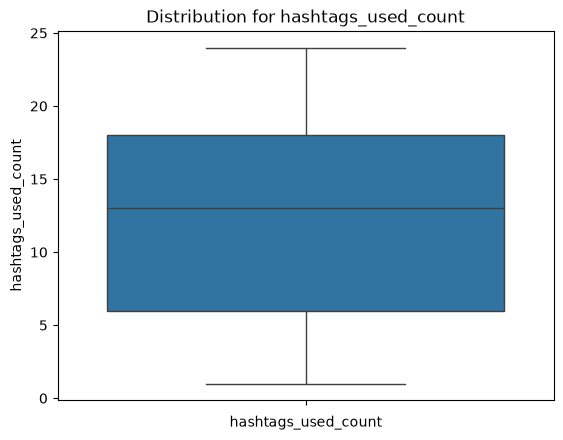

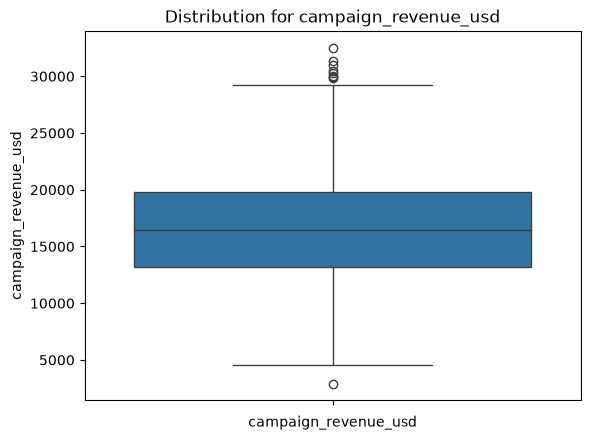

In [7]:
for col in df.describe().columns:
    showBoxPlot(df, col)

Only Campaign Revenue has outliers so Need to Remove these

In [8]:
q1 = df['campaign_revenue_usd'].quantile(0.25)
q3 = df['campaign_revenue_usd'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df = df[(df['campaign_revenue_usd'] >= lower_bound) & (df['campaign_revenue_usd'] <= upper_bound)]

In [9]:
df.shape

(2991, 13)

The filter removed 9 rows using the 1.5 × IQR rule on the target column, `campaign_revenue_usd`. Removing target outliers changes the population the model learns from, so interpret later results as applying to campaigns within the retained revenue range. The feature distributions were not filtered by this step.

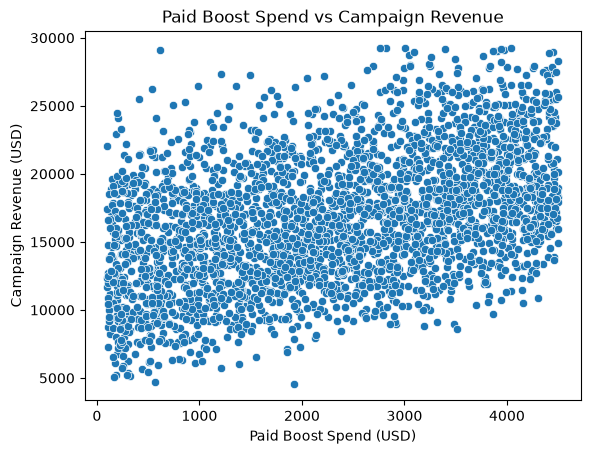

In [10]:
sns.scatterplot(
    data=df,
    x="paid_boost_spend_usd",
    y="campaign_revenue_usd"
)

plt.title("Paid Boost Spend vs Campaign Revenue")
plt.xlabel("Paid Boost Spend (USD)")
plt.ylabel("Campaign Revenue (USD)")
plt.show()

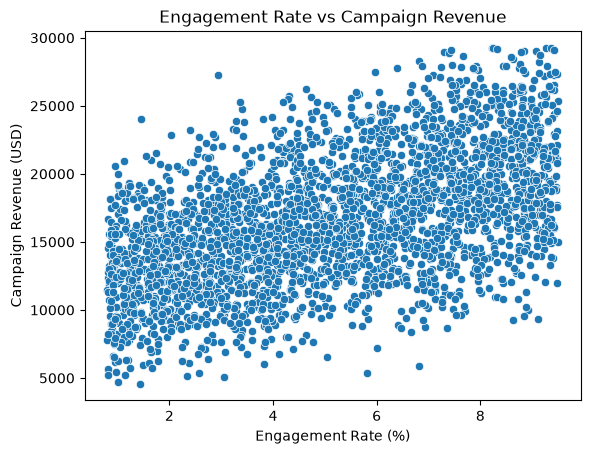

In [11]:
sns.scatterplot(data=df,x="engagement_rate_pct",y="campaign_revenue_usd")

plt.title("Engagement Rate vs Campaign Revenue")
plt.xlabel("Engagement Rate (%)")
plt.ylabel("Campaign Revenue (USD)")
plt.show()

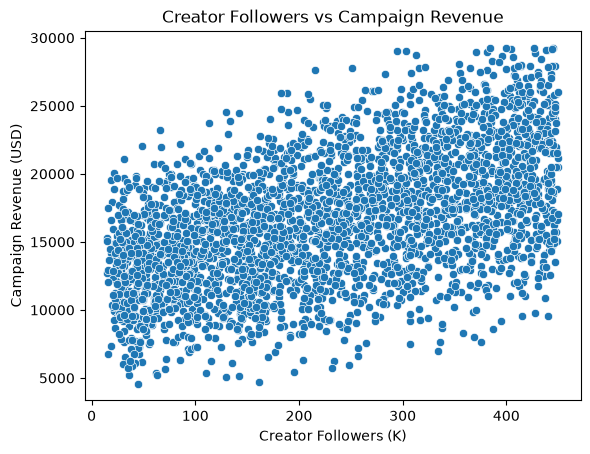

In [12]:
sns.scatterplot(data=df,x="creator_followers_k",y="campaign_revenue_usd")

plt.title("Creator Followers vs Campaign Revenue")
plt.xlabel("Creator Followers (K)")
plt.ylabel("Campaign Revenue (USD)")
plt.show()

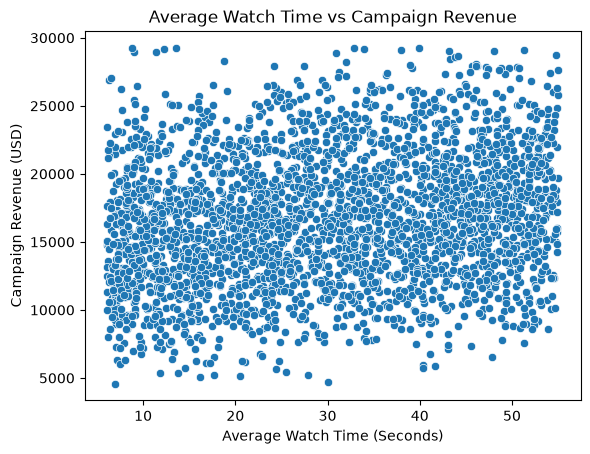

In [13]:
sns.scatterplot(data=df,x="avg_watch_time_sec",y="campaign_revenue_usd")

plt.title("Average Watch Time vs Campaign Revenue")
plt.xlabel("Average Watch Time (Seconds)")
plt.ylabel("Campaign Revenue (USD)")
plt.show()

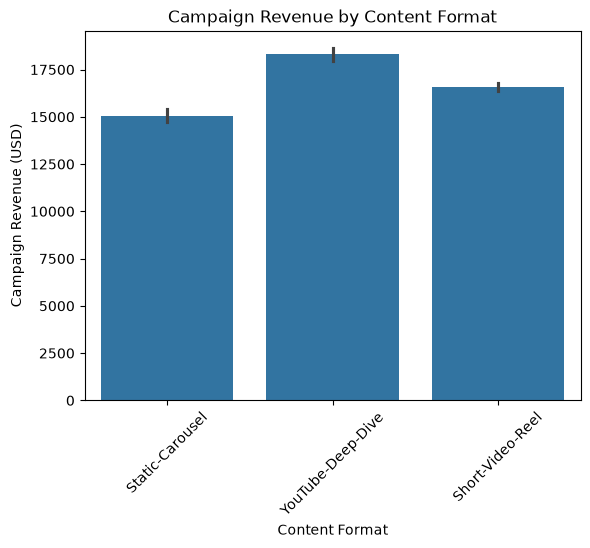

In [14]:
sns.barplot(data=df,x="content_format",y="campaign_revenue_usd")

plt.title("Campaign Revenue by Content Format")
plt.xlabel("Content Format")
plt.ylabel("Campaign Revenue (USD)")
plt.xticks(rotation=45)
plt.show()

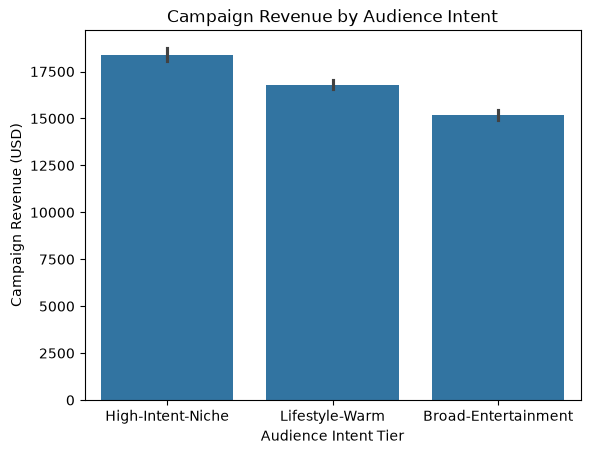

In [15]:
sns.barplot(data=df,x="audience_intent_tier",y="campaign_revenue_usd")

plt.title("Campaign Revenue by Audience Intent")
plt.xlabel("Audience Intent Tier")
plt.ylabel("Campaign Revenue (USD)")
plt.show()

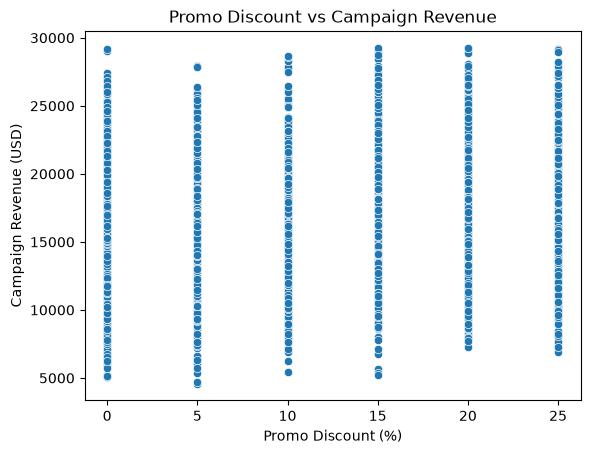

In [16]:
sns.scatterplot(data=df,x="promo_discount_pct",y="campaign_revenue_usd")

plt.title("Promo Discount vs Campaign Revenue")
plt.xlabel("Promo Discount (%)")
plt.ylabel("Campaign Revenue (USD)")
plt.show()

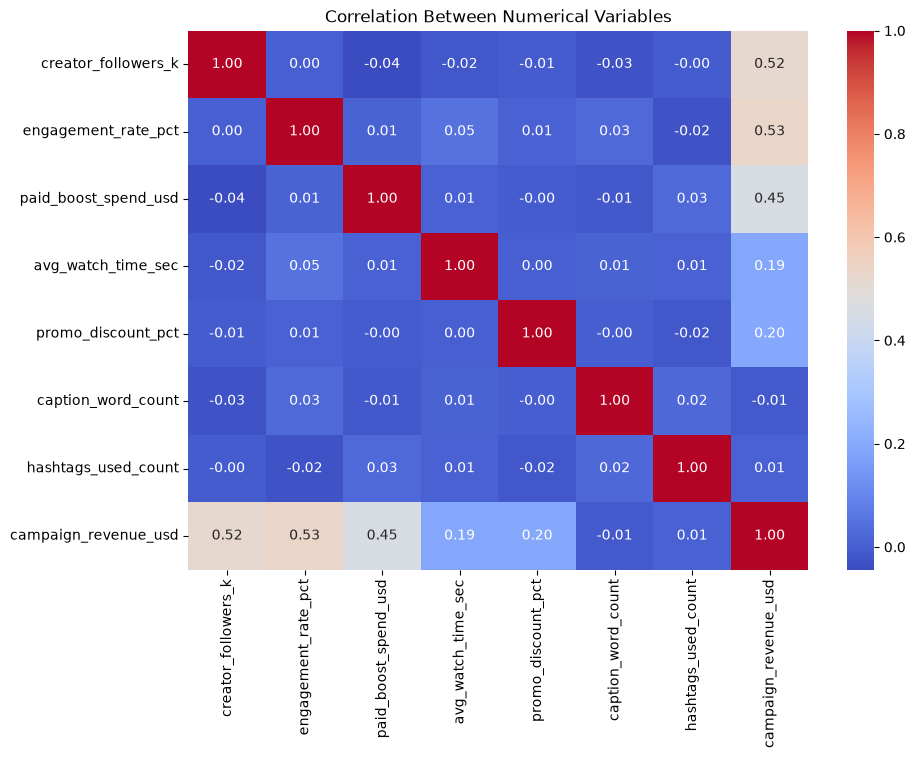

In [17]:
numeric_cols = df.select_dtypes(include="number")

corr = numeric_cols.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Between Numerical Variables")
plt.show()

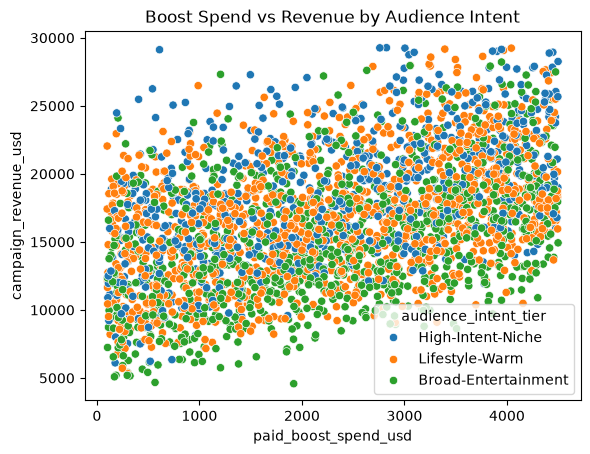

In [18]:
sns.scatterplot(data=df,x="paid_boost_spend_usd",y="campaign_revenue_usd",hue="audience_intent_tier")

plt.title("Boost Spend vs Revenue by Audience Intent")
plt.show()

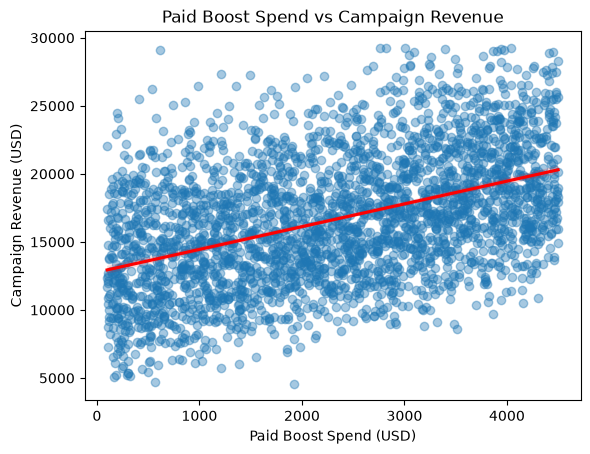

In [19]:
sns.regplot(data=df,x="paid_boost_spend_usd",y="campaign_revenue_usd",scatter_kws={"alpha": 0.4},line_kws={"color": "red"})

plt.title("Paid Boost Spend vs Campaign Revenue")
plt.xlabel("Paid Boost Spend (USD)")
plt.ylabel("Campaign Revenue (USD)")
plt.show()

In [20]:
numeric_cols = [
    "creator_followers_k",
    "engagement_rate_pct",
    "paid_boost_spend_usd",
    "avg_watch_time_sec",
    "promo_discount_pct",
    "caption_word_count",
    "hashtags_used_count",
    "campaign_revenue_usd"
]

df[numeric_cols].corr()["campaign_revenue_usd"].sort_values(ascending=False)

campaign_revenue_usd    1.000000
engagement_rate_pct     0.533403
creator_followers_k     0.515816
paid_boost_spend_usd    0.453725
promo_discount_pct      0.195109
avg_watch_time_sec      0.191687
hashtags_used_count     0.007897
caption_word_count     -0.009494
Name: campaign_revenue_usd, dtype: float64

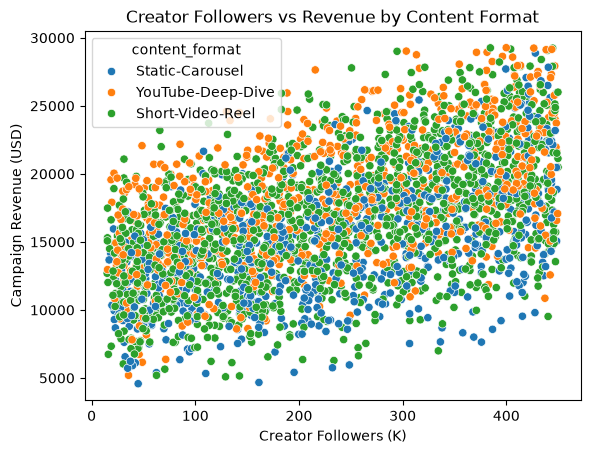

In [21]:
sns.scatterplot(data=df,x="creator_followers_k",y="campaign_revenue_usd",hue="content_format")

plt.title("Creator Followers vs Revenue by Content Format")
plt.xlabel("Creator Followers (K)")
plt.ylabel("Campaign Revenue (USD)")
plt.show()

In [22]:
display(df.describe(include="O").columns)

/var/folders/41/49dnj5213l1f6btjl3b5rdlh0000gn/T/ipykernel_16849/4047706636.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="O").columns)


Index(['content_format', 'audience_intent_tier', 'creator_phone_os',
       'contract_payment_terms', 'posting_day_weather'],
      dtype='str')

In [23]:
df["contract_payment_terms"].value_counts()

contract_payment_terms
Net-15     1018
Net-30      997
Upfront     976
Name: count, dtype: int64

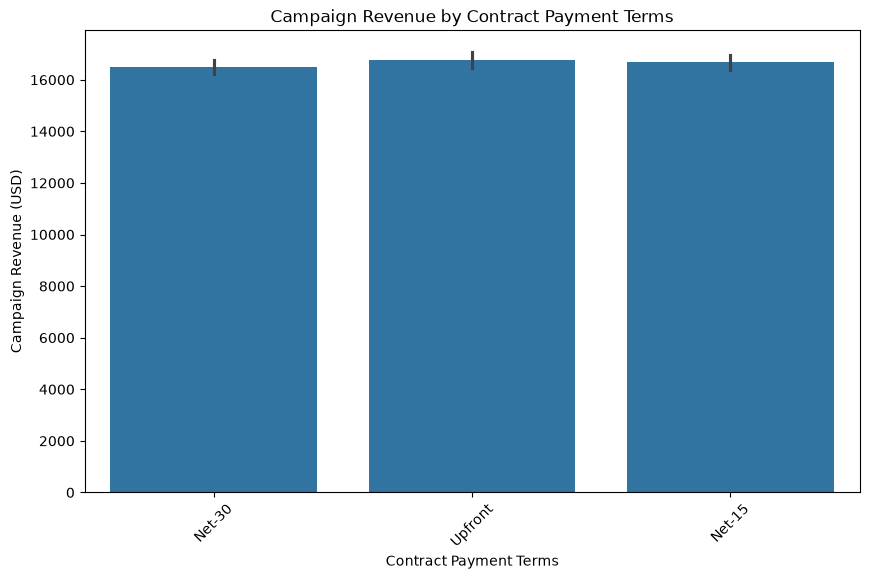

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df,x="contract_payment_terms",y="campaign_revenue_usd")

plt.title("Campaign Revenue by Contract Payment Terms")
plt.xlabel("Contract Payment Terms")
plt.ylabel("Campaign Revenue (USD)")
plt.xticks(rotation=45)

plt.show()

In [25]:
df.groupby("contract_payment_terms")[
    "campaign_revenue_usd"
].agg(["count", "mean", "median"]).sort_values(
    "mean",
    ascending=False
)

,count,mean,median
contract_payment_terms,,,
Upfront,976,16764.543084,16553.750
Net-15,1018,16673.911218,16482.145
Net-30,997,16501.084183,16380.770


In [26]:
df["posting_day_weather"].value_counts()

posting_day_weather
Sunny     1020
Cloudy    1018
Rainy      953
Name: count, dtype: int64

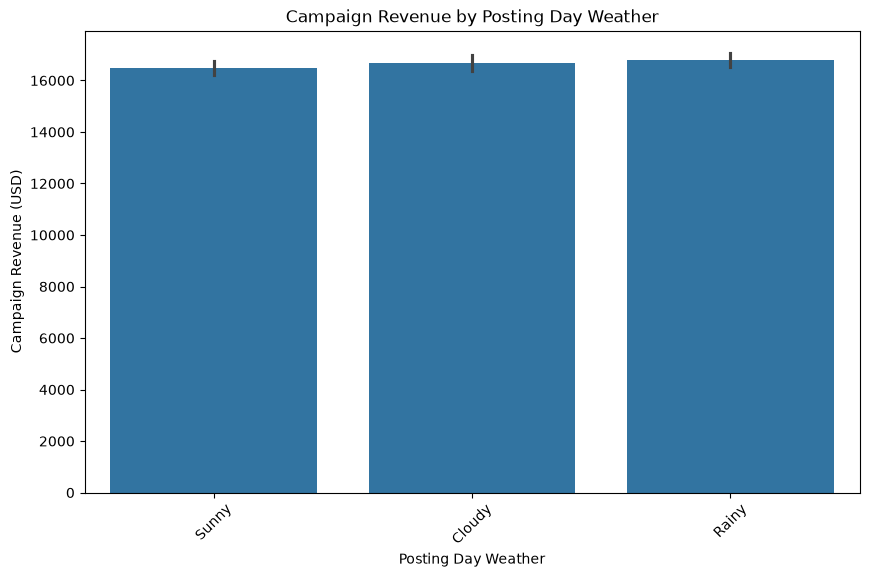

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="posting_day_weather",
    y="campaign_revenue_usd"
)

plt.title("Campaign Revenue by Posting Day Weather")
plt.xlabel("Posting Day Weather")
plt.ylabel("Campaign Revenue (USD)")
plt.xticks(rotation=45)

plt.show()

In [28]:
df["creator_phone_os"].value_counts()

creator_phone_os
Android    1527
iOS        1464
Name: count, dtype: int64

In [29]:
df.groupby("posting_day_weather")["campaign_revenue_usd"].agg(["count", "mean", "median"]).sort_values("mean",ascending=False)

,count,mean,median
posting_day_weather,,,
Rainy,953,16792.934124,16539.70
Cloudy,1018,16675.462240,16414.01
Sunny,1020,16478.950804,16482.69


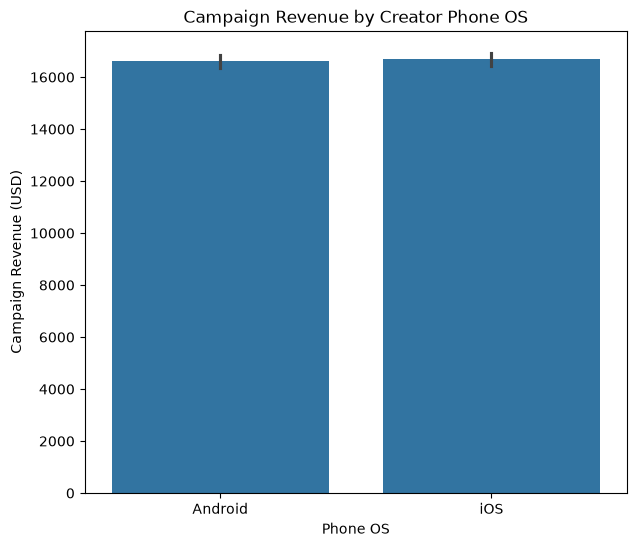

In [30]:
plt.figure(figsize=(7, 6))

sns.barplot(data=df,x="creator_phone_os",y="campaign_revenue_usd")

plt.title("Campaign Revenue by Creator Phone OS")
plt.xlabel("Phone OS")
plt.ylabel("Campaign Revenue (USD)")

plt.show()

In [31]:
df.groupby("creator_phone_os")["campaign_revenue_usd"].agg(["count", "mean", "median"]).sort_values("mean",ascending=False)

,count,mean,median
creator_phone_os,,,
iOS,1464,16680.031981,16474.59
Android,1527,16613.130177,16449.24


### EDA Summary

The charts and group summaries examine how campaign revenue varies across numeric features and categories. Scatter plots show observed relationships, while bar plots and grouped means compare category-level revenue. These are exploratory patterns, not evidence that a feature causes revenue to change; category counts should also be considered when interpreting averages.

## Data Preprocessing

The null-value check indicates that missing-value imputation is not needed for this dataset. The following steps select the predictors for this modeling pass and convert the retained categorical columns into numeric indicator columns so scikit-learn estimators can use them. Excluded fields are omitted from this model; that does not establish that they are unimportant in general.

In [32]:
categorical_cols = df.describe(include="O").columns
display(categorical_cols)

/var/folders/41/49dnj5213l1f6btjl3b5rdlh0000gn/T/ipykernel_16849/2663690350.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.describe(include="O").columns


Index(['content_format', 'audience_intent_tier', 'creator_phone_os',
       'contract_payment_terms', 'posting_day_weather'],
      dtype='str')

In [33]:
df.drop(columns=["creator_phone_os", "posting_day_weather", "contract_payment_terms", "caption_word_count", "hashtags_used_count", "avg_watch_time_sec", "promo_discount_pct"], inplace=True)

In [34]:
df = pd.get_dummies(df, columns=["content_format", "audience_intent_tier"])


In [35]:
df.head()

,creator_followers_k,engagement_rate_pct,paid_boost_spend_usd,campaign_revenue_usd,content_format_Short-Video-Reel,content_format_Static-Carousel,content_format_YouTube-Deep-Dive,audience_intent_tier_Broad-Entertainment,audience_intent_tier_High-Intent-Niche,audience_intent_tier_Lifestyle-Warm
0,425.4,2.14,1331,15192.26,False,True,False,False,True,False
1,171.3,5.73,3925,20018.44,False,False,True,False,False,True
2,356.4,8.03,1817,21146.87,True,False,False,False,True,False
3,272.2,7.70,942,17639.62,True,False,False,False,False,True
4,143.0,6.06,3347,17375.60,True,False,False,True,False,False


In [36]:
df.shape

(2991, 10)

In [37]:
for col in df.columns:
    # Corelation between all variables and campaign revenue
    corr = df[col].corr(df["campaign_revenue_usd"])
    print(f"Correlation between {col} and campaign_revenue_usd: {corr:.2f}")

Correlation between creator_followers_k and campaign_revenue_usd: 0.52
Correlation between engagement_rate_pct and campaign_revenue_usd: 0.53
Correlation between paid_boost_spend_usd and campaign_revenue_usd: 0.45
Correlation between campaign_revenue_usd and campaign_revenue_usd: 1.00
Correlation between content_format_Short-Video-Reel and campaign_revenue_usd: -0.01
Correlation between content_format_Static-Carousel and campaign_revenue_usd: -0.19
Correlation between content_format_YouTube-Deep-Dive and campaign_revenue_usd: 0.20
Correlation between audience_intent_tier_Broad-Entertainment and campaign_revenue_usd: -0.22
Correlation between audience_intent_tier_High-Intent-Niche and campaign_revenue_usd: 0.22
Correlation between audience_intent_tier_Lifestyle-Warm and campaign_revenue_usd: 0.03


The correlation values summarize pairwise linear association with revenue for the features retained at this point. Correlation is useful for screening and interpretation, but it does not measure a feature's causal effect and may miss nonlinear relationships or interactions.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error

In [39]:
X = df.drop(columns=["campaign_revenue_usd"])
y = df["campaign_revenue_usd"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, random_state=42, test_size=0.2)

display(X_train.shape)
display(X_test.shape)
display(Y_train.shape)
display(Y_test.shape)

(2392, 9)

(599, 9)

(2392,)

(599,)

In [40]:
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 19.84, 963.31, 1.73,...,-1594.31, 1664.44, -70.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['creator_followers_k','engagement_rate_pct','paid_boost_spend_usd',..., 'audience_intent_tier_Broad-Entertainment', 'audience_intent_tier_High-Intent-Niche', 'audience_intent_tier_Lifestyle-Warm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3229
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [41]:
display(linear_model.coef_)
display(linear_model.intercept_)

array([   19.83971337,   963.31095358,     1.73107775,    26.37991842,
       -1626.52274103,  1600.14282261, -1594.30671131,  1664.43627344,
         -70.12956213])

np.float64(3229.3072502036885)

In [42]:
y_pred = linear_model.predict(X_test)

print("R² score :", round(r2_score(Y_test, y_pred), 3))
print("MAE      :", round(mean_absolute_error(Y_test, y_pred)))
print("RMSE     :", round(root_mean_squared_error(Y_test, y_pred), 2))

R² score : 0.891
MAE      : 1254
RMSE     : 1555.99


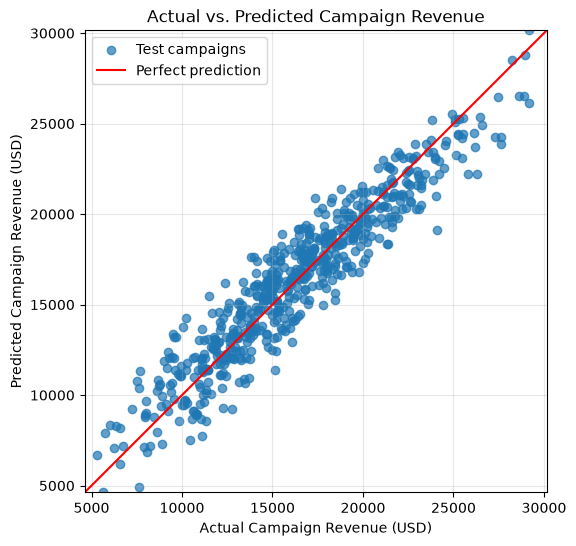

In [43]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_pred, alpha=0.7, label="Test campaigns")

plot_min = min(Y_test.min(), y_pred.min())
plot_max = max(Y_test.max(), y_pred.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], color="red", linestyle="-", label="Perfect prediction")

plt.title("Actual vs. Predicted Campaign Revenue")
plt.xlabel("Actual Campaign Revenue (USD)")
plt.ylabel("Predicted Campaign Revenue (USD)")
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Linear Regression Baseline

Linear Regression provides a baseline by fitting a linear relationship between the selected features and campaign revenue. The coefficient values describe the fitted direction and magnitude for each feature while the others are held constant, subject to the feature encoding and units. R² summarizes variance explained, while MAE and RMSE summarize prediction error in revenue units. In the actual-versus-predicted plot, points nearer the red diagonal have smaller errors; this model uses the earlier 80/20 split.

In [44]:
from sklearn.preprocessing import PolynomialFeatures

In [45]:
polynomial_features = PolynomialFeatures(degree=2)
X_poly = polynomial_features.fit_transform(X)


X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.3, random_state=42)

print("Polynomial Training rows:", len(X_train_poly))
print("Polynomial Testing rows :", len(X_test_poly))

Polynomial Training rows: 2093
Polynomial Testing rows : 898


In [46]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](55,)","[-0. , 3.92, 2.43,..., 0.01, 0. , 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7184
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,55
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](55,)","[2.74e+08,1.59e+07,1.55e+06,...,3.04e-08,3.04e-08,3.02e-08]"


In [47]:
y_pred_poly = model_poly.predict(X_test_poly)

r2_poly = r2_score(y_test_poly, y_pred_poly)
mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
rmse_ploy = root_mean_squared_error(y_test_poly, y_pred_poly)

print(f"Polynomial Regression R² score: {r2_poly:.3f}")
print(f"Polynomial Regression MAE      : {mae_poly:.2f}")
print(f"Polynomial Regression RMSE     : {rmse_ploy:.2f}")

# Linear Model Performance:
# R² score : 0.891
# MAE      : 1254
# RMSE     : 1555.99

Polynomial Regression R² score: 0.896
Polynomial Regression MAE      : 1211.65
Polynomial Regression RMSE     : 1510.63


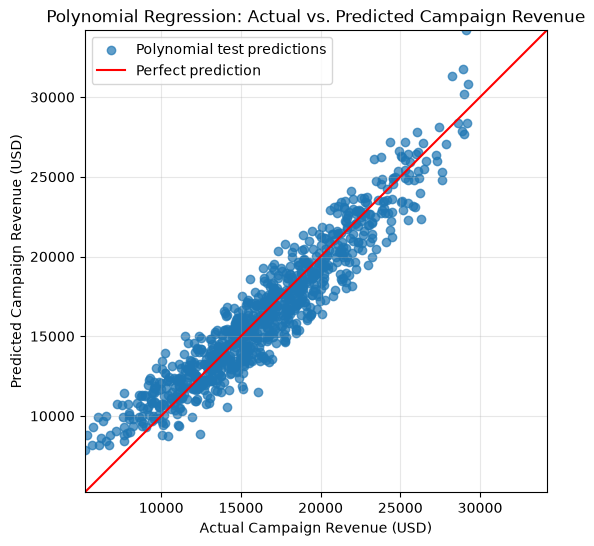

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_poly, y_pred_poly, alpha=0.7, label="Polynomial test predictions")

plot_min = min(y_test_poly.min(), y_pred_poly.min())
plot_max = max(y_test_poly.max(), y_pred_poly.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], color="red", linestyle="-", label="Perfect prediction")

plt.title("Polynomial Regression: Actual vs. Predicted Campaign Revenue")
plt.xlabel("Actual Campaign Revenue (USD)")
plt.ylabel("Predicted Campaign Revenue (USD)")
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Polynomial Regression

PolynomialFeatures expands the original inputs with degree-two terms, allowing Linear Regression to model some curvature and pairwise interactions. The model's predictions and metrics are evaluated on the earlier 70/30 split. Because this split differs from the later train/validation/test split, its reported score should not be treated as a direct head-to-head comparison with the models below.

In [49]:
df.head()

,creator_followers_k,engagement_rate_pct,paid_boost_spend_usd,campaign_revenue_usd,content_format_Short-Video-Reel,content_format_Static-Carousel,content_format_YouTube-Deep-Dive,audience_intent_tier_Broad-Entertainment,audience_intent_tier_High-Intent-Niche,audience_intent_tier_Lifestyle-Warm
0,425.4,2.14,1331,15192.26,False,True,False,False,True,False
1,171.3,5.73,3925,20018.44,False,False,True,False,False,True
2,356.4,8.03,1817,21146.87,True,False,False,False,True,False
3,272.2,7.70,942,17639.62,True,False,False,False,False,True
4,143.0,6.06,3347,17375.60,True,False,False,True,False,False


In [50]:
X = df.drop('campaign_revenue_usd', axis=1)
y = df['campaign_revenue_usd']
#70% → Training, 30% → Temporary
X_train, X_temp, y_train, y_temp = train_test_split(X, y,test_size=0.30,random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.50,random_state=42)

## Holdout Split for Model Selection

The data is split into 70% training, 15% validation, and 15% test sets. Models are fitted on the training set, validation data is used to choose hyperparameters, and the test set is held back for the final evaluation. Keeping the test set separate from tuning gives a more honest estimate of performance.

In [51]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
encoded_cols = X_train.select_dtypes(include=['bool']).columns

print("Numerical:", list(numerical_cols))
print("Encoded:", list(encoded_cols))

Numerical: ['creator_followers_k', 'engagement_rate_pct', 'paid_boost_spend_usd']
Encoded: ['content_format_Short-Video-Reel', 'content_format_Static-Carousel', 'content_format_YouTube-Deep-Dive', 'audience_intent_tier_Broad-Entertainment', 'audience_intent_tier_High-Intent-Niche', 'audience_intent_tier_Lifestyle-Warm']


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsRegressor


In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', 'passthrough', encoded_cols)
    ]
)

In [54]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

The preprocessing transformer standardizes numerical columns using statistics learned from the training data and passes the one-hot encoded columns through unchanged. Validation and test data are transformed with the same training-fitted transformer, preventing those held-out rows from influencing the scaling parameters. Scaling is especially important for KNN because distance calculations depend on feature magnitudes.

In [55]:
display(X_train_processed.shape)
display(y_train.shape)

(2093, 9)

(2093,)

In [56]:
for k in range(3, 35, 2):

    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_processed, y_train)
    y_val_pred = knn.predict(X_val_processed)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    print("k =", k, "Validation RMSE =", rmse)
    


k = 3 Validation RMSE = 1655.5776063592573
k = 5 Validation RMSE = 1587.8381667958324
k = 7 Validation RMSE = 1596.7908947076073
k = 9 Validation RMSE = 1589.702341407321
k = 11 Validation RMSE = 1598.6572468043476
k = 13 Validation RMSE = 1600.264830699804
k = 15 Validation RMSE = 1630.525364914317
k = 17 Validation RMSE = 1650.3957806935414
k = 19 Validation RMSE = 1673.270193586693
k = 21 Validation RMSE = 1692.5235140013028
k = 23 Validation RMSE = 1702.2974246292658
k = 25 Validation RMSE = 1708.735968158801
k = 27 Validation RMSE = 1707.9032787210235
k = 29 Validation RMSE = 1708.476708634568
k = 31 Validation RMSE = 1723.5728509381654
k = 33 Validation RMSE = 1732.1066590748812


In [57]:
best_k = 5
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_processed, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


### K-Nearest Neighbors (KNN)

KNN predicts a campaign's revenue from nearby campaigns in the scaled feature space. The loop evaluates odd values of `k` on the validation set using RMSE; smaller validation RMSE indicates better average error in revenue units. The selected `k` is then fitted on the training data, leaving the test set for final evaluation.

In [58]:
from sklearn.tree import DecisionTreeRegressor

In [59]:
tree_depth = [ 3, 5, 7, 9, 11, 13, 15 ]

for depth in tree_depth:
    tree = DecisionTreeRegressor(
        random_state=42,
        max_depth=depth
    )
    tree.fit(X_train_processed, y_train)
    y_val_pred = tree.predict(X_val_processed)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print("Depth =", depth, "Validation RMSE =", rmse)

Depth = 3 Validation RMSE = 2964.3700167907323
Depth = 5 Validation RMSE = 2544.6442637205837
Depth = 7 Validation RMSE = 2370.21874916103
Depth = 9 Validation RMSE = 2370.9518055161607
Depth = 11 Validation RMSE = 2310.0451759052125
Depth = 13 Validation RMSE = 2414.334922817567
Depth = 15 Validation RMSE = 2404.24751691158


In [60]:
best_depth = 7
tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=best_depth
)
tree.fit(X_train_processed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``

### Decision Tree

The decision tree tuning loop compares maximum-depth settings by validation RMSE. Limiting tree depth constrains model complexity and can reduce overfitting. The final tree uses a depth of 7 and is fitted only on the training partition; the test set remains reserved for evaluation.

In [61]:
from sklearn.ensemble import RandomForestRegressor

In [62]:
tree_values = [100, 150, 200, 250, 300]
tree_depth = [ 5, 7, 9, 11, 13 ]

for n in tree_values:
    for depth in tree_depth:
        rf = RandomForestRegressor(
            n_estimators=n,
            random_state=42,
            max_depth=depth
        )
        rf.fit(X_train_processed, y_train)
        y_val_pred = rf.predict(X_val_processed)
        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        print("n_estimators =", n, "max_depth =", depth, "Validation RMSE =", rmse)
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        max_depth=10
    )
    rf.fit(X_train_processed, y_train)
    y_val_pred = rf.predict(X_val_processed)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print("n_estimators =", n, "Validation RMSE =", rmse)

n_estimators = 100 max_depth = 5 Validation RMSE = 2166.043874924447
n_estimators = 100 max_depth = 7 Validation RMSE = 1800.4118204882018
n_estimators = 100 max_depth = 9 Validation RMSE = 1666.4451236014422
n_estimators = 100 max_depth = 11 Validation RMSE = 1644.5215499895778
n_estimators = 100 max_depth = 13 Validation RMSE = 1645.586811629837
n_estimators = 100 Validation RMSE = 1651.1305733697666
n_estimators = 150 max_depth = 5 Validation RMSE = 2169.9979186410783
n_estimators = 150 max_depth = 7 Validation RMSE = 1801.6877255065988
n_estimators = 150 max_depth = 9 Validation RMSE = 1663.2415179988232
n_estimators = 150 max_depth = 11 Validation RMSE = 1639.0731059646691
n_estimators = 150 max_depth = 13 Validation RMSE = 1641.091292360249
n_estimators = 150 Validation RMSE = 1644.2834433940197
n_estimators = 200 max_depth = 5 Validation RMSE = 2164.602330337476
n_estimators = 200 max_depth = 7 Validation RMSE = 1801.4200302638083
n_estimators = 200 max_depth = 9 Validation RMSE

### Random Forest Tuning

The grid search compares tree counts and maximum depths using validation RMSE. In the recorded results, 200 trees at depth 11 scored slightly better than 300 trees at depth 11 (about 1637.32 versus 1637.65). The final model below is configured with 100 trees and depth 11; confirm that this is the intended choice from the full validation results before treating it as the best configuration.

In [63]:
best_n = 100
best_depth = 11

rf = RandomForestRegressor(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=42,
)
rf.fit(X_train_processed, y_train)
rf_y_test_pred = rf.predict(X_test_processed)

rmse = np.sqrt(mean_squared_error(y_test, rf_y_test_pred))
print("Random Forest Test RMSE =", rmse)


Random Forest Test RMSE = 1750.5980859888564


The final Random Forest is evaluated on the held-out test set after its settings have been selected. Test RMSE is in the same units as campaign revenue, so it estimates the typical scale of prediction error while penalizing larger errors more strongly. Avoid adjusting model settings in response to this test result.

## Model Comparison

The table scores the existing fitted models against the later 15% test partition. R² is better when higher; MSE and MAE are better when lower. MSE is measured in squared revenue units and is more sensitive to large errors, while MAE is in revenue units. The Linear and Polynomial Regression models were fitted earlier with different train/test splits, so their training data may overlap this later test partition. Treat their scores as descriptive rather than a controlled comparison; KNN, Decision Tree, and Random Forest use the later 70/15/15 split.

In [64]:
comparison_predictions = {
    "Linear Regression": linear_model.predict(X_test),
    "Polynomial Regression": model_poly.predict(
        polynomial_features.transform(X_test)
    ),
    "KNN": knn.predict(X_test_processed),
    "Decision Tree": tree.predict(X_test_processed),
    "Random Forest": rf.predict(X_test_processed),
}

comparison_table = pd.DataFrame(
    [
        {
            "Model": model_name,
            "R² Score": r2_score(y_test, predictions),
            "Mean Squared Error": mean_squared_error(y_test, predictions),
            "Mean Absolute Error": mean_absolute_error(y_test, predictions),
        }
        for model_name, predictions in comparison_predictions.items()
    ]
).sort_values("Mean Squared Error").reset_index(drop=True)

display(comparison_table.round(3))

,Model,R² Score,Mean Squared Error,Mean Absolute Error
0,Linear Regression,0.888,2451062.958,1258.755
1,Polynomial Regression,0.885,2513884.666,1268.016
2,KNN,0.873,2793342.117,1338.194
3,Random Forest,0.860,3064593.659,1423.727
4,Decision Tree,0.743,5641304.719,1916.192


### Reading the Comparison

Use the metric directions above when reviewing the table, and compare models only when they were evaluated on the same unseen rows. On the current run, the values summarize predictions from the existing fitted objects; the different split history for Linear and Polynomial Regression limits any ranking across all five models.

In [65]:
import pickle

In [66]:
with open("../models/linear_regression_model.pkl", "wb") as f:
    pickle.dump(linear_model, f)

Choosing Linear Regression because of Best Performing in my case

## Predict Revenue for a New Campaign

The saved Linear Regression model uses these inputs:

- `creator_followers_k`: creator followers measured in thousands (for example, enter `250` for 250,000 followers).
- `engagement_rate_pct`: engagement rate as the numeric percentage shown in the dataset (for example, enter `5.0` for 5%).
- `paid_boost_spend_usd`: paid promotion spend in USD.
- `content_format`: choose one of the listed formats.
- `audience_intent_tier`: choose one of the listed audience tiers.

Run the code cell below, edit the five example values to describe a campaign, and run it again. The cell loads the saved model from `../models/linear_regression_model.pkl` and creates the one-hot encoded fields in the exact order expected by that model. The prediction estimates campaign revenue in USD, not profit; it does not subtract creator fees, discounts, or other costs.

In [67]:
with open("../models/linear_regression_model.pkl", "rb") as model_file:
    prediction_model = pickle.load(model_file)

expected_features = list(prediction_model.feature_names_in_)
content_format_options = [
    feature.removeprefix("content_format_")
    for feature in expected_features
    if feature.startswith("content_format_")
]
audience_intent_options = [
    feature.removeprefix("audience_intent_tier_")
    for feature in expected_features
    if feature.startswith("audience_intent_tier_")
]

print("Content format choices:", content_format_options)
print("Audience intent choices:", audience_intent_options)

# Edit these values for the campaign you want to predict.
creator_followers_k = 250.0
engagement_rate_pct = 5.0
paid_boost_spend_usd = 1500.0
content_format = "Short-Video-Reel"
audience_intent_tier = "High-Intent-Niche"

if content_format not in content_format_options:
    raise ValueError(f"Choose content_format from: {content_format_options}")
if audience_intent_tier not in audience_intent_options:
    raise ValueError(f"Choose audience_intent_tier from: {audience_intent_options}")

prediction_input = {
    "creator_followers_k": creator_followers_k,
    "engagement_rate_pct": engagement_rate_pct,
    "paid_boost_spend_usd": paid_boost_spend_usd,
}
prediction_input.update(
    {
        feature: feature == f"content_format_{content_format}"
        for feature in expected_features
        if feature.startswith("content_format_")
    }
)
prediction_input.update(
    {
        feature: feature == f"audience_intent_tier_{audience_intent_tier}"
        for feature in expected_features
        if feature.startswith("audience_intent_tier_")
    }
)

prediction_row = pd.DataFrame([prediction_input]).reindex(columns=expected_features)
predicted_revenue_usd = prediction_model.predict(prediction_row)[0]

display(prediction_row)
print(f"Predicted campaign revenue: ${predicted_revenue_usd:,.2f} USD")

Content format choices: ['Short-Video-Reel', 'Static-Carousel', 'YouTube-Deep-Dive']
Audience intent choices: ['Broad-Entertainment', 'High-Intent-Niche', 'Lifestyle-Warm']


,creator_followers_k,engagement_rate_pct,paid_boost_spend_usd,content_format_Short-Video-Reel,content_format_Static-Carousel,content_format_YouTube-Deep-Dive,audience_intent_tier_Broad-Entertainment,audience_intent_tier_High-Intent-Niche,audience_intent_tier_Lifestyle-Warm
0,250.0,5.0,1500.0,True,False,False,False,True,False


Predicted campaign revenue: $17,293.22 USD
